# 📊 Void Survivor - PPO Training Statistics & Visualization
This notebook automatically scans the workspace, parent directory, and Downloads folder for TensorBoard log files (`events.out.tfevents.*`) and directories (e.g., `Downloads/1/`). It extracts, calculates, and visualizes the training metrics of your reinforcement learning agent (PPO).

Whenever you run a new training or have new log folders, simply run this notebook again to fetch and analyze the latest parameters.

In [1]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

# Try to import tensorboard, install if missing
try:
    from tensorboard.backend.event_processing.event_accumulator import EventAccumulator
except ImportError:
    print("tensorboard not found, installing via pip...")
    import sys
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "tensorboard"])
    from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

print("✅ Core libraries loaded successfully!")

✅ Core libraries loaded successfully!


In [2]:
# Paths to search for log files or log directories
search_paths = [
    ".",                                           # current directory
    "../",                                          # Desktop (parent of void_survivor)
    os.path.expanduser("~/Downloads"),              # Downloads folder
    os.path.expanduser("~/Downloads/1")             # Specific '1' folder in Downloads
]

runs = []

for base_path in search_paths:
    if not os.path.exists(base_path):
        continue
        
    # Check if the folder itself contains many tfevents files (meaning it is a run directory)
    direct_files = glob.glob(os.path.join(base_path, "events.out.tfevents.*"))
    if len(direct_files) > 5:
        mtime = max(os.path.getmtime(f) for f in direct_files)
        runs.append({
            'type': 'directory',
            'path': os.path.abspath(base_path),
            'name': f"📁 Folder: {os.path.basename(base_path)} ({len(direct_files)} files)",
            'mtime': mtime
        })
        
    # Check subdirectories
    for entry in os.scandir(base_path):
        if entry.is_dir() and not entry.name.startswith('.'):
            sub_files = glob.glob(os.path.join(entry.path, "events.out.tfevents.*"))
            if sub_files:
                mtime = max(os.path.getmtime(f) for f in sub_files)
                runs.append({
                    'type': 'directory',
                    'path': os.path.abspath(entry.path),
                    'name': f"📁 Folder: {entry.name} ({len(sub_files)} files)",
                    'mtime': mtime
                })
                
    # Check for individual files (only if we didn't add its parent folder as a run directory)
    for f in direct_files:
        parent_added = any(r['type'] == 'directory' and r['path'] == os.path.abspath(base_path) for r in runs)
        if not parent_added:
            mtime = os.path.getmtime(f)
            runs.append({
                'type': 'file',
                'path': os.path.abspath(f),
                'name': f"📄 File: {os.path.basename(f)}",
                'mtime': mtime
            })

# De-duplicate runs based on path
unique_runs = {}
for r in runs:
    unique_runs[r['path']] = r
runs = list(unique_runs.values())

# Sort runs by modification time (newest first)
runs.sort(key=lambda r: r['mtime'], reverse=True)

if not runs:
    raise FileNotFoundError("❌ No TensorBoard log files or folders found!")

print("✅ Available runs and folders found:")
for idx, r in enumerate(runs):
    time_str = datetime.fromtimestamp(r['mtime']).strftime('%Y-%m-%d %H:%M:%S')
    print(f"  [{idx}] {r['name']} (Last Update: {time_str})")

# --- CONFIGURATION CELL ---
# Modify this index to select another run/folder from the list above
selected_idx = 0
selected_run = runs[selected_idx]
print(f"\n👉 Selected run for analysis: {selected_run['name']}")

✅ Available runs and folders found:
  [0] 📄 File: events.out.tfevents.1781011386.ADMIN.19160.465 (Last Update: 2026-06-09 23:54:45)
  [1] 📁 Folder: void_survivor (1 files) (Last Update: 2026-06-09 23:54:45)
  [2] 📄 File: events.out.tfevents.1781011386.ADMIN.19160.465 (Last Update: 2026-06-09 23:54:33)
  [3] 📁 Folder: 1 (466 files) (Last Update: 2026-06-09 20:23:39)

👉 Selected run for analysis: 📄 File: events.out.tfevents.1781011386.ADMIN.19160.465


In [3]:
selected_path = selected_run['path']
is_dir = selected_run['type'] == 'directory'

if is_dir:
    print(f"Parsing run folder: {selected_path}")
    event_files = glob.glob(os.path.join(selected_path, "events.out.tfevents.*"))
    # Sort numerically by suffix to preserve iteration order
    def get_suffix(filepath):
        try:
            return int(filepath.split('.')[-1])
        except ValueError:
            return -1
    event_files.sort(key=get_suffix)
else:
    print(f"Parsing single event file: {selected_path}")
    event_files = [selected_path]

print(f"Processing {len(event_files)} file(s)... This may take a moment.")

tag_data = {}
for f in event_files:
    suffix = get_suffix(f) if is_dir else 0
    if suffix == -1:
        continue
    try:
        ea = EventAccumulator(f)
        ea.Reload()
        scalar_tags = ea.Tags().get('scalars', [])
        for tag in scalar_tags:
            events = ea.Scalars(tag)
            if tag not in tag_data:
                tag_data[tag] = []
            for e in events:
                tag_data[tag].append({
                    'step': e.step,
                    'value': e.value,
                    'time': e.wall_time,
                    'iteration': suffix # Save the iteration number from file suffix
                })
    except Exception as e:
        print(f"Warning: failed to read {os.path.basename(f)}: {e}")

# Convert to DataFrames
data = {}
for tag, events_list in tag_data.items():
    df = pd.DataFrame(events_list)
    # Sort by step/iteration and remove duplicates
    df = df.drop_duplicates(subset=['step']).sort_values('step').reset_index(drop=True)
    df = df.rename(columns={'value': tag})
    data[tag] = df

print(f"\n✅ Successfully loaded {len(data)} metrics across {len(event_files)} file(s)!")

Parsing single event file: /Users/vducc3110/Desktop/void_survivor/events.out.tfevents.1781011386.ADMIN.19160.465
Processing 1 file(s)... This may take a moment.

✅ Successfully loaded 12 metrics across 1 file(s)!


In [4]:
# --- COMPUTE DERIVED METRICS ---
latest_step = 0
for tag, df in data.items():
    if not df.empty:
        latest_step = max(latest_step, df['step'].max())

steps_list = []
for tag, df in data.items():
    if not df.empty:
        steps_list.extend(df['step'].tolist())
steps_list = sorted(list(set(steps_list)))

step_interval = 16384
if len(steps_list) >= 2:
    diffs = [steps_list[i+1] - steps_list[i] for i in range(len(steps_list)-1) if steps_list[i+1] - steps_list[i] > 0]
    if diffs:
        step_interval = min(diffs)

n_epochs = 10
total_iterations = latest_step // step_interval
total_updates = total_iterations * n_epochs

# Session iterations & elapsed time
first_time = None
latest_time = None
for tag, df in data.items():
    if not df.empty:
        if first_time is None or df['time'].min() < first_time:
            first_time = df['time'].min()
        if latest_time is None or df['time'].max() > latest_time:
            latest_time = df['time'].max()

time_elapsed = 0
if first_time is not None and latest_time is not None:
    time_elapsed = int(latest_time - first_time)

if is_dir:
    # For folder: the number of files corresponds to the number of iterations in this session
    session_iterations = len(event_files)
else:
    session_iterations = len(data.get('train/loss', []))
    if session_iterations == 0:
        first_step = min(steps_list) if steps_list else latest_step
        session_iterations = (latest_step - first_step) // step_interval + 1

# Add derived DataFrames to data dict
data['time/total_timesteps'] = pd.DataFrame({'step': [latest_step], 'time/total_timesteps': [latest_step], 'time': [latest_time]})
data['time/time_elapsed'] = pd.DataFrame({'step': [latest_step], 'time/time_elapsed': [time_elapsed], 'time': [latest_time]})
data['time/iterations'] = pd.DataFrame({'step': [latest_step], 'time/iterations': [session_iterations], 'time': [latest_time]})
data['train/n_updates'] = pd.DataFrame({'step': [latest_step], 'train/n_updates': [total_updates], 'time': [latest_time]})

summary_data = []
for tag, df in sorted(data.items()):
    if not df.empty:
        latest_row = df.iloc[-1]
        summary_data.append({
            'Metric': tag,
            'Value': latest_row[tag],
            'Step': int(latest_row['step'])
        })

summary_df = pd.DataFrame(summary_data)

from IPython.display import display, HTML

html_style = """
<style>
.premium-table {
    font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;
    border-collapse: collapse;
    width: 100%;
    max-width: 600px;
    margin: 20px 0;
    font-size: 14px;
    box-shadow: 0 4px 6px rgba(0,0,0,0.1);
    border-radius: 8px;
    overflow: hidden;
}
.premium-table th {
    background-color: #2F3E46;
    color: white;
    text-align: left;
    padding: 12px 15px;
    font-weight: 600;
}
.premium-table td {
    padding: 10px 15px;
    border-bottom: 1px solid #CAD2C5;
}
.premium-table tr:nth-child(even) {
    background-color: #F8F9FA;
}
.premium-table tr:hover {
    background-color: #ECEFE6;
    transition: background-color 0.2s ease;
}
.category-header {
    font-weight: bold;
    color: #354F52;
    background-color: #E8EAE6 !important;
}
</style>
"""

table_html = "<table class='premium-table'><thead><tr><th>Metric Group / Name</th><th>Value</th><th>Step</th></tr></thead><tbody>"

categories = {}
for _, row in summary_df.iterrows():
    parts = row['Metric'].split('/')
    cat = parts[0] + '/' if len(parts) > 1 else 'general/'
    name = parts[1] if len(parts) > 1 else parts[0]
    if cat not in categories:
        categories[cat] = []
    categories[cat].append((name, row['Value'], row['Step']))
    
for cat, items in sorted(categories.items()):
    table_html += f"<tr class='category-header'><td colspan='3'>{cat}</td></tr>"
    for name, val, step in sorted(items):
        if cat == 'time/' and name == 'time_elapsed':
            # Format duration nicely
            hours, rem = divmod(int(val), 3600)
            minutes, seconds = divmod(rem, 60)
            if hours > 0:
                val_str = f"{hours}h {minutes}m {seconds}s"
            else:
                val_str = f"{minutes}m {seconds}s"
        elif isinstance(val, (int, float)):
            if val == int(val):
                val_str = f"{int(val):,}"
            else:
                val_str = f"{val:,.6g}"
        else:
            val_str = str(val)
        table_html += f"<tr><td>&nbsp;&nbsp;&nbsp;&nbsp;{name}</td><td><strong>{val_str}</strong></td><td>{step:,}</td></tr>"
table_html += "</tbody></table>"

print("📊 SUMMARY OF LATEST TRAINING METRICS")
display(HTML(html_style + table_html))

📊 SUMMARY OF LATEST TRAINING METRICS


/var/folders/03/773zl61j52n9m_v9gxmp2hph0000gn/T/ipykernel_73395/1338224915.py:65: UserWarning: Glyph 128640 (\N{ROCKET}) missing from font(s) Arial.
  plt.tight_layout(rect=[0, 0, 1, 0.95])
/Users/vducc3110/Library/Python/3.14/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128640 (\N{ROCKET}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


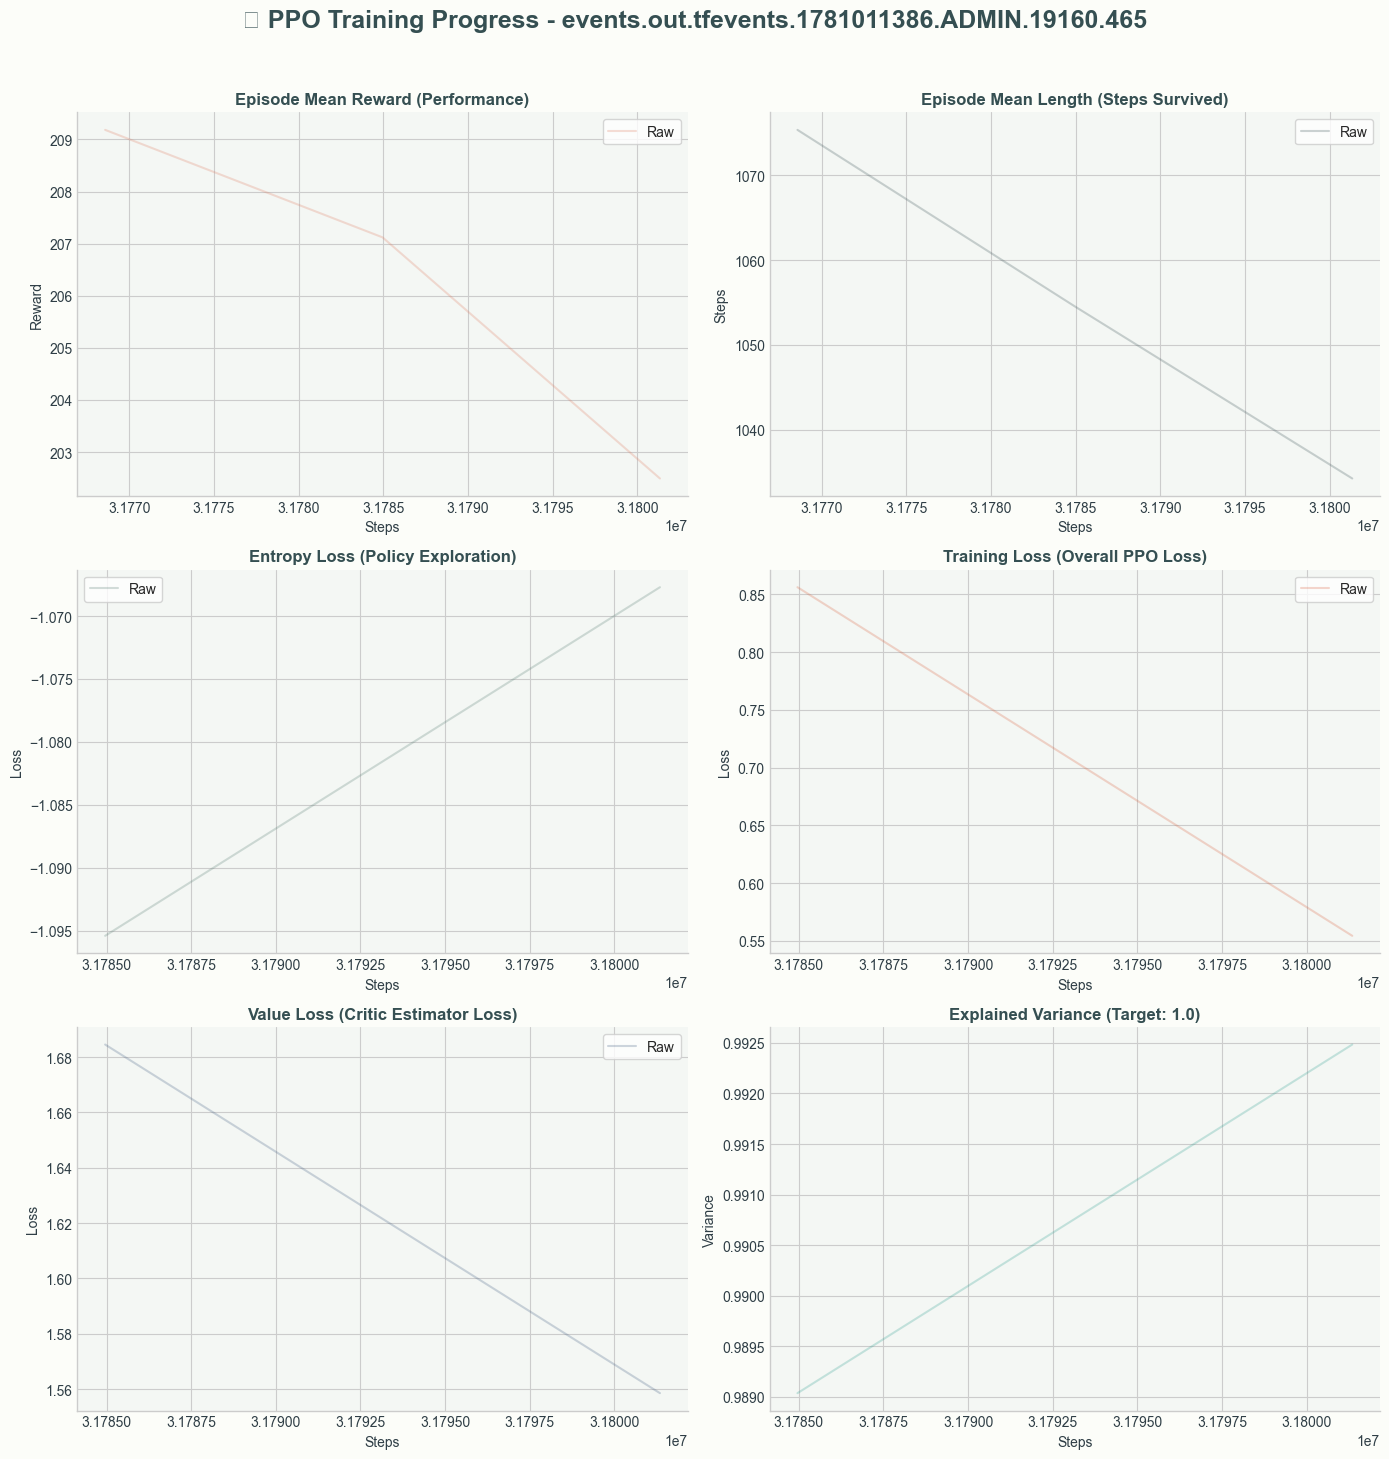

In [5]:
# Set plotting styles
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['figure.facecolor'] = '#FCFDF9'
plt.rcParams['axes.facecolor'] = '#F4F7F4'

primary_color = '#354F52'
secondary_color = '#52796F'
accent_color = '#84A98C'
highlight_color = '#E07A5F'

# Choose X-axis column and label dynamically based on run type
x_col = 'iteration' if is_dir else 'step'
x_label = 'Iteration Number (0 - 465)' if is_dir else 'Steps'

fig, axes = plt.subplots(3, 2, figsize=(14, 15))
fig.suptitle(f"🚀 PPO Training Progress - {os.path.basename(selected_path)}", fontsize=18, fontweight='bold', color=primary_color, y=0.97)

def plot_metric(ax, tag, title, color, ylabel, smooth=True):
    if tag in data and not data[tag].empty:
        df = data[tag]
        x_vals = df[x_col].values
        values = df[tag].values
        
        # Plot raw values
        ax.plot(x_vals, values, color=color, alpha=0.25, label='Raw' if smooth else None)
        
        if smooth and len(values) > 5:
            # Adaptive window sizing for smoothing
            window = max(2, len(values) // 20)
            smoothed = df[tag].rolling(window=window, min_periods=1).mean()
            ax.plot(x_vals, smoothed, color=color, linewidth=2.5, label=f'Smooth (w={window})')
            
        ax.set_title(title, fontsize=12, fontweight='semibold', color=primary_color)
        ax.set_xlabel(x_label, fontsize=10, color='#2F3E46')
        ax.set_ylabel(ylabel, fontsize=10, color='#2F3E46')
        ax.tick_params(colors='#2F3E46')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        if smooth:
            ax.legend(frameon=True, facecolor='white', framealpha=0.8)
    else:
        ax.text(0.5, 0.5, f"Metric '{tag}' not found", ha='center', va='center', fontsize=12, color='gray')
        ax.set_title(title, fontsize=12, color='gray')
        ax.axis('off')

# Plot 1: Episode Reward
plot_metric(axes[0, 0], 'rollout/ep_rew_mean', 'Episode Mean Reward (Performance)', highlight_color, 'Reward')

# Plot 2: Episode Length
plot_metric(axes[0, 1], 'rollout/ep_len_mean', 'Episode Mean Length (Steps Survived)', primary_color, 'Steps')

# Plot 3: Entropy Loss
plot_metric(axes[1, 0], 'train/entropy_loss', 'Entropy Loss (Policy Exploration)', secondary_color, 'Loss')

# Plot 4: Total Loss
plot_metric(axes[1, 1], 'train/loss', 'Training Loss (Overall PPO Loss)', '#D95D39', 'Loss')

# Plot 5: Value Loss
plot_metric(axes[2, 0], 'train/value_loss', 'Value Loss (Critic Estimator Loss)', '#3D5A80', 'Loss')

# Plot 6: Explained Variance
plot_metric(axes[2, 1], 'train/explained_variance', 'Explained Variance (Target: 1.0)', '#2A9D8F', 'Variance', smooth=False)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

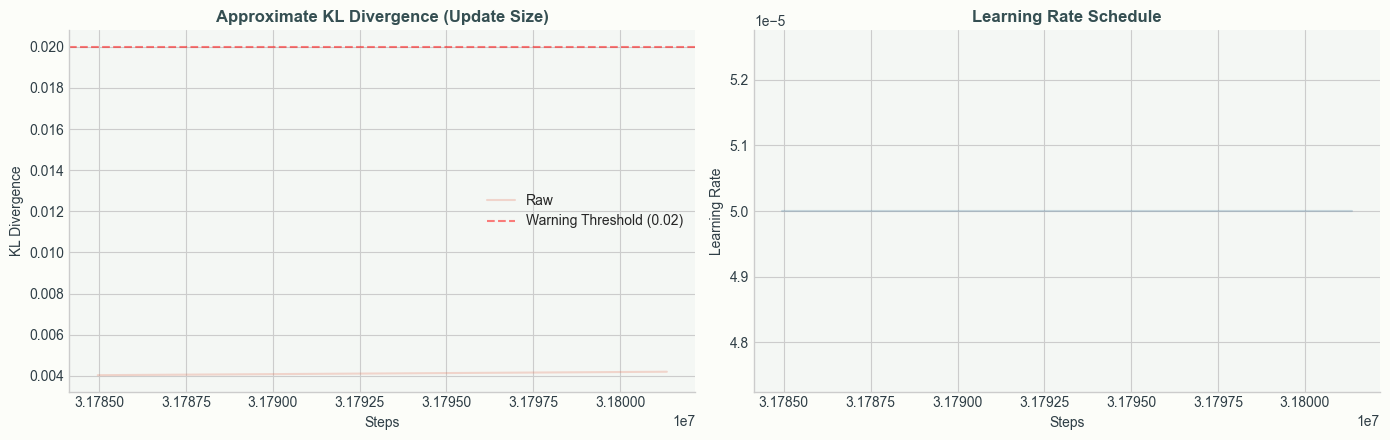

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
fig.patch.set_facecolor('#FCFDF9')

# Plot Approx KL
plot_metric(axes[0], 'train/approx_kl', 'Approximate KL Divergence (Update Size)', '#E76F51', 'KL Divergence', smooth=True)
if 'train/approx_kl' in data and len(data['train/approx_kl']) > 1:
    axes[0].axhline(y=0.02, color='red', linestyle='--', alpha=0.5, label='Warning Threshold (0.02)')
    axes[0].legend()

# Plot Learning Rate
plot_metric(axes[1], 'train/learning_rate', 'Learning Rate Schedule', '#457B9D', 'Learning Rate', smooth=False)

plt.tight_layout()
plt.show()

## 🔍 Reinforcement Learning (PPO) Metric Guide

### 1. Rollout Metrics
- **`rollout/ep_rew_mean` (Episode Reward Mean)**: Average reward the agent receives per episode. **Higher is better**. It indicates that the agent is learning to achieve objectives (e.g. dodging bullets, surviving, killing enemies).
- **`rollout/ep_len_mean` (Episode Length Mean)**: Average number of frames/steps survived per episode. **Higher is better**. In a bullet-hell game, surviving longer is the primary objective.

### 2. Time & Progress Metrics
- **`time/total_timesteps`**: The accumulated training steps from the beginning of training (across runs).
- **`time/iterations`**: The number of iterations in the **current training session**.
- **`time/time_elapsed`**: Time elapsed (in seconds) of the **current training session**.
- **`time/fps`**: Steps processed by the environment per second. Higher means faster training.

### 3. Loss Metrics
- **`train/loss` (Total Loss)**: Overall loss of the network updates. PPO loss fluctuates significantly compared to supervised learning. Bounded fluctuations are normal; explosive spikes indicate instability.
- **`train/entropy_loss` (Entropy Loss)**: Measures policy randomness. Since it is defined as `-ent_coef * entropy` inside the optimizer, a **more negative** value means more exploration. It should gradually move closer to 0 (become less negative) as the agent gains confidence and consolidates its strategies.
- **`train/value_loss` (Value Loss)**: Loss of the critic network estimating state values. A decreasing/low value loss means the critic has high confidence in predicting expected future rewards.
- **`train/n_updates`**: Total number of gradient descent updates applied to the policy network across all iterations.

### 4. Training Stability
- **`train/approx_kl` (Approximate KL Divergence)**: Measures how much the policy changes at each update step. If it consistently goes **above 0.02**, updates are too drastic, which can corrupt policy weights and cause catastrophic forgetting.
- **`train/explained_variance` (Explained Variance)**: Measures the accuracy of the value function predicting the returns. Scale is between `-inf` and `1.0`. A value close to **1.0** means the value function matches target values perfectly. Negative values mean the predictions are worse than guessing the mean.